In [ ]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import Image, display

# dataset dirs follow conf/dataset/*/default.yaml: ${root}/${dataset.dir}
DATA = Path('/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data')
SOC_NPZ = DATA / 'sort_of_clevr-seed1-train36000-test1000-q10-t-1' / 'test.npz'
SQOOP_NPZ = DATA / 'sqoop-seed0-train1080000-test25600-rhs18' / 'val_seen.npz'

OUT_DIR = Path('./outputs') / 'figures'
CHAP_DATASETS = OUT_DIR / 'chap:datasets'
CHAP_RESULTS = OUT_DIR / 'chap:results'
CHAP_DATASETS.mkdir(parents=True, exist_ok=True)
CHAP_RESULTS.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 140,
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
})


def save_show(fig, name, dir):
    path = dir / f'{name}.png'
    fig.savefig(path)
    plt.close(fig)
    display(Image(path))

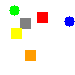

In [ ]:
soc = np.load(SOC_NPZ, allow_pickle=False)
scene = 0
plt.imsave(CHAP_DATASETS / 'soc_example.png', soc['images'][scene][..., ::-1])
display(Image(CHAP_DATASETS / 'soc_example.png'))

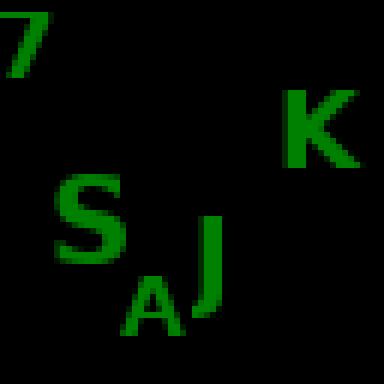

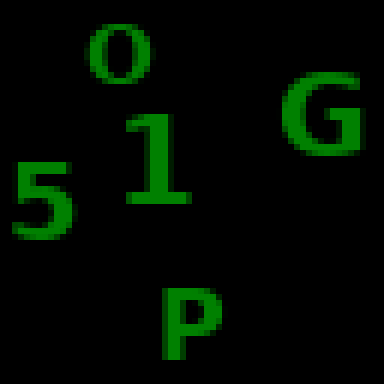

In [ ]:
sq = np.load(SQOOP_NPZ, allow_pickle=True)
for i in range(2):
    plt.imsave(CHAP_DATASETS / f'sqoop_example_{i}.png', np.kron(sq['images'][i], np.ones((6, 6, 1), dtype=np.uint8)))
    display(Image(CHAP_DATASETS / f'sqoop_example_{i}.png'))

In [ ]:
ENTITY, TAG = 'niks_priv', 'v16'
SOC, SQ = 'sort_of_clevr', 'sqoop'
PAIR_VARIETY = [1, 2, 4, 8, 18, 35]
T_TEST = [1, 2, 4, 6, 8, 12, 16]

CANON = {SOC: 'bd2c173785',
         SQ: {1: '7c2f6df64c', 2: 'bb06c3147a', 4: '1bb0efa51c', 8: 'affb5412a5', 18: '9f272ac176', 35: '2b9eec406d'}}

MAIN = {
    SOC: {'Q-Only': '5c938564b4', 'CNN+MLP': '7f69d35494', 'RelNet': '1bba57eaba', 'FiLM': 'cce2a7dc79',
          'Transformer': 'd50b23e608', 'Workspace': 'e2b5f79b1c', 'SyncNet': CANON[SOC]},
    SQ: {'Q-Only':      {1: 'da868e47f3', 2: '8c385b2059', 4: 'b53f5ecb08', 8: 'c7cfb0dd1c', 18: 'd640141c57', 35: 'a09acf017b'},
         'Conv+LSTM':   {1: '4dd2f8a5f6', 2: 'b838865278', 4: '11380cec6a', 8: '125ce8d50e', 18: '6828367e4c', 35: 'd6cbb5b004'},
         'RelNet':      {1: 'd91b42c323', 2: '41515ce582', 4: '46ef70288f', 8: 'f15b7d0159', 18: 'fd877702cb', 35: '18a92d8762'},
         'FiLM':        {1: '48c351e38b', 2: 'cbbfbd61a7', 4: '13e08caaa4', 8: '70f71488ff', 18: '4cf87adb37', 35: 'dd57cc6026'},
         'Transformer': {1: 'e5acac883a', 2: 'bd94a19a03', 4: '10eb8e1433', 8: '007a9674ee', 18: '17110fa882', 35: '13222c0aab'},
         'Workspace':   {1: '58a944c267', 2: '61a49532b2', 4: 'd12abb2e78', 8: 'fe996cfc81', 18: 'f3743655aa', 35: 'fa00371d63'},
         'SyncNet':     CANON[SQ]},
}

ABLATION_ROWS = ['canonical', 'no_bias', 'hard_partition', 'anchors_off', 'cells_off', 'silent', 'static_addr',
                 'lines_attn', 'with_prior_term', 'seed_random', 'cnn_stem']
ABLATIONS = {
    SOC:    {'canonical': CANON[SOC], 'no_bias': 'd7072ec57d', 'hard_partition': '3986545b38', 'anchors_off': '96cb2d6dc8',
             'cells_off': '8fbb02c9c0', 'silent': '77baf6a31a', 'static_addr': 'b09a365569', 'lines_attn': 'bbb6a6f7eb',
             'with_prior_term': None, 'seed_random': None, 'cnn_stem': '5f683fd1b5'},
    (SQ, 1):  {'canonical': CANON[SQ][1], 'no_bias': '6917200a5f', 'hard_partition': 'c30768ddf4', 'anchors_off': None,
               'cells_off': None, 'silent': 'c9c95bda21', 'static_addr': '1beba23c65', 'lines_attn': 'e582e0c1eb',
               'with_prior_term': None, 'seed_random': None, 'cnn_stem': None},
    (SQ, 18): {'canonical': CANON[SQ][18], 'no_bias': '20182acf1b', 'hard_partition': 'fc23127fcc', 'anchors_off': None,
               'cells_off': None, 'silent': 'a1142183d7', 'static_addr': '9daf23bd7b', 'lines_attn': '0e17b36177',
               'with_prior_term': None, 'seed_random': 'b14851cdf7', 'cnn_stem': None},
}

SWEEP_AXES = {'t_train': [2, 4, 8, 16], 'phase_dim': [2, 3, 4, 6, 8], 'n_modules': [4, 6, 8, 12]}
SWEEPS = {
    SOC:     {'t_train':   {2: '2b9e6b890b', 4: '0ddfd86b22', 8: CANON[SOC], 16: '50c47b416e'},
              'phase_dim': {2: 'ca9c20344c', 3: '4c476b02eb', 4: 'a9b3ddbed9', 6: CANON[SOC], 8: 'f545ccea93'},
              'n_modules': {4: '0b69be29f7', 6: CANON[SOC], 8: 'cc1f364afe', 12: '7352fba590'}},
    (SQ, 1): {'t_train':   {2: None, 4: None, 8: CANON[SQ][1], 16: None},
              'phase_dim': {2: None, 3: None, 4: None, 6: CANON[SQ][1], 8: None},
              'n_modules': {4: None, 6: CANON[SQ][1], 8: None, 12: None}},
}

SEEDING = {
    (SQ, 18): {'partition 1': 'b912886f99', 'partition 2': '30100689be', 'partition 4': CANON[SQ][18], 'partition 8': '5d7d8e020a',
               'partition 50': 'fc23127fcc', 'random': 'b14851cdf7', 'zero': '5f58c04ab4'},
    SOC:      {'learned': CANON[SOC], 'partition': None, 'random': None},
}

BASELINE_VARIANTS = {
    (SQ, 18): {'Transformer': {'patchify': '17110fa882', 'stem': None, 'stem + batch 2048': None},
               'Workspace':   {'patchify': 'f3743655aa', 'stem': None, 'stem + batch 2048': None},
               'RelNet':      {'5x5': 'fd877702cb', '8x8': None},
               'Conv+LSTM':   {'base': '6828367e4c', 'tuned': None}},
    SOC:      {'Transformer': {'patchify': 'd50b23e608', 'stem': None, 'stem + 4 layers': None},
               'Workspace':   {'patchify': 'e2b5f79b1c', 'stem': None},
               'RelNet':      {'5x5': '1bba57eaba', '8x8': None}},
}

METRICS = {SOC: {'Overall': 'test_callbacks/accuracy', 'Non-relational': 'test_callbacks/non_relational_accuracy',
                 'Binary': 'test_callbacks/binary_accuracy', 'Ternary': 'test_callbacks/ternary_accuracy'},
           SQ:  {'validation': 'eval_callbacks/accuracy', 'held-out': 'test_callbacks/accuracy'}}
SUBTYPES = {'Non-relational': {'Query shape': 'query_shape', 'Left of centre': 'left_of_centre', 'Top half': 'top_half'},
            'Binary':         {'Closest shape': 'closest_shape', 'Furthest shape': 'furthest_shape', 'Count same shape': 'count_same_shape'},
            'Ternary':        {'Count in box': 'count_in_box', 'On band': 'on_band', 'Count obtuse': 'count_obtuse'}}
T_VARIANCE = {'Overall': 't_variance/acc_mean_T{}', 'Binary': 't_variance/binary_mean_T{}', 'Ternary': 't_variance/ternary_mean_T{}'}
INTERVENTIONS = {'Freeze': 'phase_freeze', 'Zero': 'phase_zero', 'Shuffle': 'phase_shuffle', 'Anchor shuffle': 'anchor_shuffle'}
ASSEMBLED = ('test_callbacks/ternary_accuracy', 0.70)
FAMILIES = list(METRICS[SOC])

TABLES = OUT_DIR / 'tables'
TABLES.mkdir(parents=True, exist_ok=True)

In [5]:
REFRESH = False


def fetch(project):
    try:
        import wandb
        runs = wandb.Api(timeout=120).runs(f'{ENTITY}/{project}', filters={'tags': TAG, 'state': 'finished'})
        df = pd.json_normalize([{'created': str(r.created_at), **r.config,
                                 **{k: v for k, v in r.summary.items() if isinstance(v, (int, float))}}
                                for r in runs])
    except Exception as e:                              # offline / no API key
        print(f'{project}: wandb API unavailable ({e!r}); reading wandb_export_*.csv')
        df = pd.concat(pd.read_csv(p, low_memory=False) for p in Path('.').glob('wandb_export_*.csv'))
        df = df[(df['dataset.name'] == project) & (df['State'] == 'finished')].rename(columns={'Created': 'created'})
        if 'cfg_hash' not in df:
            df['cfg_hash'] = df['Tags'].str.extract(r'cfg:(\w{10})')[0]
    return df.sort_values('created').drop_duplicates(['cfg_hash', 'train.seed'], keep='last')   # latest run per seed


if REFRESH or 'RUNS' not in globals():
    RUNS = {ds: fetch(ds) for ds in (SOC, SQ)}
{ds: (len(df), df.cfg_hash.nunique()) for ds, df in RUNS.items()}


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


{'sort_of_clevr': (229, 53), 'sqoop': (376, 157)}

In [6]:
# ---------------------------------------------------------------------------
# One accessor for every number in the thesis. All accuracies are ABSOLUTE, in %.
# ---------------------------------------------------------------------------
def runs(dataset, cfg_hash):
    df = RUNS[dataset]
    return df[df.cfg_hash == cfg_hash] if cfg_hash else df.iloc[0:0]


def values(dataset, cfg_hash, col):
    r = runs(dataset, cfg_hash)
    return 100 * r[col].dropna() if col in r else pd.Series(dtype=float)


def stat(dataset, cfg_hash, col):
    v = values(dataset, cfg_hash, col)                                   # (mean, sd, n)
    return (v.mean(), v.std(ddof=1) if len(v) > 1 else 0.0, len(v)) if len(v) else (np.nan, np.nan, 0)


def fmt(dataset, cfg_hash, col):
    m, s, n = stat(dataset, cfg_hash, col)
    return '—' if np.isnan(m) else f'{m:.1f} ± {s:.1f} ({n})'


def params(dataset, cfg_hash):
    r = runs(dataset, cfg_hash)
    return '—' if 'n_params' not in r or r.n_params.dropna().empty else f'{r.n_params.dropna().iloc[0] / 1e6:.2f}M'


def assembly(cfg_hash):
    """SoC only: fraction of runs assembled, and mean accuracy over the assembled ones."""
    r = runs(SOC, cfg_hash); col, thr = ASSEMBLED
    if col not in r or r.empty: return '—', '—'
    ok = r[col] > thr
    acc = 100 * r.loc[ok, METRICS[SOC]['Overall']]
    return f'{ok.sum()}/{len(r)}', ('—' if acc.empty else f'{acc.mean():.1f}')


def table(rows, cols, dataset, save=None):
    """rows: {label: cfg_hash}; cols: {column label: wandb column}. Every cell is 'mean ± sd (n)'."""
    t = pd.DataFrame({c: {label: fmt(dataset, h, col) for label, h in rows.items()} for c, col in cols.items()})
    if save:
        t.to_csv(TABLES / f'{save}.csv'); t.to_latex(TABLES / f'{save}.tex', escape=False)
    return t


# canonical sweep values, read from the main run's config
_main = runs(SOC, MAIN[SOC]['SyncNet']).iloc[0] if len(runs(SOC, MAIN[SOC]['SyncNet'])) else pd.Series(dtype=object)
T_CANON, M_CANON, D_CANON = (int(_main[k]) if pd.notna(_main.get(k)) else d
                             for k, d in [('model.t_bus', 8), ('model.n_modules', 6), ('model.phase_dim', 6)])


In [7]:
# ======================= TABLES (each saved as csv + tex under outputs/figures/tables) =======================

# Table 5.1 -- Sort-of-CLEVR main
soc_results = table(MAIN[SOC], METRICS[SOC], SOC)
soc_results.insert(0, 'Params', [params(SOC, h) for h in MAIN[SOC].values()])
soc_results.to_csv(TABLES / 'soc_results.csv'); soc_results.to_latex(TABLES / 'soc_results.tex', escape=False)
display(soc_results)

# Table B.1 -- Sort-of-CLEVR subtypes
sub_cols = {('Overall', ''): METRICS[SOC]['Overall']}
for fam, subs in SUBTYPES.items():
    sub_cols[(fam, '')] = METRICS[SOC][fam]
    sub_cols.update({(fam, name): f'test_callbacks/{key}_accuracy' for name, key in subs.items()})
soc_subtypes = pd.DataFrame({label: {row: fmt(SOC, h, col) for row, col in sub_cols.items()} for label, h in MAIN[SOC].items()})
soc_subtypes.index.names = ['family', 'subtype']
soc_subtypes.to_csv(TABLES / 'soc_subtypes.csv'); soc_subtypes.to_latex(TABLES / 'soc_subtypes.tex', escape=False)
display(soc_subtypes)

# Table 5.x / appendix -- SQOOP by pair variety
sqoop_results = pd.DataFrame({v: {(label, split): fmt(SQ, by_v.get(v), col) for label, by_v in MAIN[SQ].items()
                                  for split, col in METRICS[SQ].items()} for v in PAIR_VARIETY})
sqoop_results.columns.name = 'pair variety'
sqoop_results.to_csv(TABLES / 'sqoop_results.csv'); sqoop_results.to_latex(TABLES / 'sqoop_results.tex', escape=False)
display(sqoop_results)


,Params,Overall,Non-relational,Binary,Ternary
Q-Only,0.02M,49.4 ± 0.2 (5),50.7 ± 0.3 (5),43.6 ± 0.5 (5),54.1 ± 0.2 (5)
CNN+MLP,1.39M,64.7 ± 0.1 (5),63.3 ± 0.3 (5),74.5 ± 0.2 (5),56.2 ± 0.2 (5)
RelNet,0.85M,87.4 ± 1.2 (5),99.9 ± 0.0 (5),95.6 ± 0.5 (5),66.6 ± 3.1 (5)
FiLM,2.78M,93.6 ± 0.4 (5),99.9 ± 0.1 (5),97.4 ± 0.2 (5),83.5 ± 0.9 (5)
Transformer,0.30M,83.9 ± 3.7 (5),100.0 ± 0.0 (5),88.8 ± 6.9 (5),63.0 ± 5.1 (5)
Workspace,0.56M,85.8 ± 4.5 (5),100.0 ± 0.0 (5),90.3 ± 6.8 (5),67.2 ± 8.0 (5)
SyncNet,0.67M,92.4 ± 0.9 (5),100.0 ± 0.0 (5),98.8 ± 0.2 (5),78.5 ± 2.7 (5)


Q-Only         CNN+MLP  \
family         subtype                                            
Overall                          49.4 ± 0.2 (5)  64.7 ± 0.1 (5)   
Non-relational                   50.7 ± 0.3 (5)  63.3 ± 0.3 (5)   
               Query shape       49.3 ± 0.8 (5)  65.5 ± 0.3 (5)   
               Left of centre    50.6 ± 0.2 (5)  62.6 ± 0.5 (5)   
               Top half          52.1 ± 0.0 (5)  61.9 ± 0.6 (5)   
Binary                           43.6 ± 0.5 (5)  74.5 ± 0.2 (5)   
               Closest shape     50.1 ± 0.6 (5)  68.2 ± 0.4 (5)   
               Furthest shape    50.4 ± 1.2 (5)  75.8 ± 0.5 (5)   
               Count same shape  29.9 ± 0.5 (5)  79.8 ± 0.2 (5)   
Ternary                          54.1 ± 0.2 (5)  56.2 ± 0.2 (5)   
               Count in box      69.6 ± 0.0 (5)  69.6 ± 0.0 (5)   
               On band           51.8 ± 0.7 (5)  57.5 ± 0.6 (5)   
               Count obtuse      40.5 ± 0.0 (5)  41.2 ± 0.3 (5)   

                                         RelNet             FiLM  \
family         subtype                                             
Overall                          87.4 ± 1.2 (5)   93.6 ± 0.4 (5)   
Non-relational                   99.9 ± 0.0 (5)   99.9 ± 0.1 (5)   
               Query shape       99.9 ± 0.0 (5)  100.0 ± 0.0 (5)   
               Left of centre    99.8 ± 0.1 (5)   99.8 ± 0.1 (5)   
               Top half          99.9 ± 0.0 (5)   99.8 ± 0.1 (5)   
Binary                           95.6 ± 0.5 (5)   97.4 ± 0.2 (5)   
               Closest shape     93.0 ± 1.0 (5)   95.5 ± 0.3 (5)   
               Furthest shape    94.1 ± 0.6 (5)   96.8 ± 0.3 (5)   
               Count same shape  99.9 ± 0.0 (5)   99.9 ± 0.1 (5)   
Ternary                          66.6 ± 3.1 (5)   83.5 ± 0.9 (5)   
               Count in box      78.2 ± 3.8 (5)   92.5 ± 0.7 (5)   
               On band           72.8 ± 3.2 (5)   89.2 ± 0.8 (5)   
               Count obtuse      48.5 ± 2.7 (5)   68.5 ± 1.3 (5)   

                                     Transformer        Workspace  \
family         subtype                                              
Overall                           83.9 ± 3.7 (5)   85.8 ± 4.5 (5)   
Non-relational                   100.0 ± 0.0 (5)  100.0 ± 0.0 (5)   
               Query shape       100.0 ± 0.0 (5)  100.0 ± 0.0 (5)   
               Left of centre    100.0 ± 0.0 (5)   99.9 ± 0.0 (5)   
               Top half          100.0 ± 0.0 (5)   99.9 ± 0.0 (5)   
Binary                            88.8 ± 6.9 (5)   90.3 ± 6.8 (5)   
               Closest shape     80.2 ± 10.9 (5)  81.2 ± 10.8 (5)   
               Furthest shape     86.7 ± 9.7 (5)  90.3 ± 10.0 (5)   
               Count same shape  100.0 ± 0.0 (5)  100.0 ± 0.0 (5)   
Ternary                           63.0 ± 5.1 (5)   67.2 ± 8.0 (5)   
               Count in box       77.5 ± 5.1 (5)   81.2 ± 7.1 (5)   
               On band            65.7 ± 7.4 (5)   72.1 ± 8.4 (5)   
               Count obtuse       45.2 ± 3.1 (5)   47.8 ± 8.7 (5)   

                                         SyncNet  
family         subtype                            
Overall                           92.4 ± 0.9 (5)  
Non-relational                   100.0 ± 0.0 (5)  
               Query shape       100.0 ± 0.0 (5)  
               Left of centre    100.0 ± 0.0 (5)  
               Top half           99.9 ± 0.1 (5)  
Binary                            98.8 ± 0.2 (5)  
               Closest shape      98.2 ± 0.3 (5)  
               Furthest shape     98.1 ± 0.2 (5)  
               Count same shape  100.0 ± 0.0 (5)  
Ternary                           78.5 ± 2.7 (5)  
               Count in box       90.2 ± 2.8 (5)  
               On band            84.7 ± 3.1 (5)  
               Count obtuse       60.1 ± 3.2 (5)

pair variety                         1                2                4   \
Q-Only      validation   50.0 ± 0.0 (3)   50.0 ± 0.0 (3)   50.0 ± 0.0 (3)   
            held-out     50.0 ± 0.0 (3)   50.0 ± 0.0 (3)   50.0 ± 0.0 (3)   
Conv+LSTM   validation   50.0 ± 0.0 (3)   50.0 ± 0.0 (3)  61.2 ± 19.4 (3)   
            held-out     50.6 ± 0.1 (3)   50.6 ± 0.2 (3)  60.0 ± 16.8 (3)   
RelNet      validation  66.7 ± 28.9 (3)   50.0 ± 0.0 (3)   50.0 ± 0.0 (3)   
            held-out    56.3 ± 10.4 (3)   50.0 ± 0.1 (3)   50.0 ± 0.0 (3)   
FiLM        validation  100.0 ± 0.0 (3)  100.0 ± 0.0 (3)  100.0 ± 0.0 (3)   
            held-out     69.2 ± 1.4 (3)   76.9 ± 1.4 (3)   87.4 ± 1.2 (3)   
Transformer validation   50.0 ± 0.0 (3)   50.0 ± 0.1 (3)   50.0 ± 0.0 (3)   
            held-out     50.0 ± 0.0 (3)   50.1 ± 0.2 (3)   50.1 ± 0.1 (3)   
Workspace   validation  57.2 ± 12.5 (3)   64.5 ± 8.2 (3)  57.5 ± 11.8 (3)   
            held-out     52.0 ± 3.5 (3)   59.5 ± 5.8 (3)  56.6 ± 10.3 (3)   
SyncNet     validation  100.0 ± 0.0 (3)                —                —   
            held-out     77.2 ± 7.1 (3)                —                —   

pair variety                         8                18               35  
Q-Only      validation   50.0 ± 0.0 (3)   50.0 ± 0.0 (5)   50.0 ± 0.0 (3)  
            held-out     50.0 ± 0.0 (3)   50.0 ± 0.0 (5)   50.0 ± 0.0 (3)  
Conv+LSTM   validation   50.0 ± 0.0 (3)   50.0 ± 0.0 (5)  62.1 ± 19.8 (3)  
            held-out     50.5 ± 0.3 (3)   50.4 ± 0.5 (5)  63.2 ± 20.6 (3)  
RelNet      validation   50.0 ± 0.0 (3)   50.0 ± 0.0 (5)   50.2 ± 0.3 (3)  
            held-out     50.0 ± 0.2 (3)   50.1 ± 0.2 (5)   50.1 ± 0.2 (3)  
FiLM        validation  100.0 ± 0.0 (3)  100.0 ± 0.0 (5)  87.4 ± 21.8 (3)  
            held-out     97.7 ± 1.1 (3)   99.3 ± 0.6 (5)  87.4 ± 21.8 (3)  
Transformer validation   50.0 ± 0.0 (3)   50.0 ± 0.0 (5)   50.0 ± 0.0 (3)  
            held-out     50.0 ± 0.0 (3)   50.0 ± 0.0 (5)   50.0 ± 0.1 (3)  
Workspace   validation   57.0 ± 9.1 (3)   59.3 ± 9.4 (5)  56.5 ± 10.5 (3)  
            held-out     56.9 ± 8.9 (3)   59.3 ± 9.3 (5)  56.6 ± 10.6 (3)  
SyncNet     validation                —  100.0 ± 0.0 (3)                —  
            held-out                  —   99.0 ± 1.0 (3)                —

In [8]:
# Table 5.2 -- ablations, both tasks side by side (SoC: accuracy, assembled-only accuracy, rate; SQOOP: held-out at 1 and 18)
rows = list(ABLATIONS[SOC])
ablations = pd.DataFrame(index=rows)
ablations['SoC accuracy'] = [fmt(SOC, ABLATIONS[SOC][r], METRICS[SOC]['Overall']) for r in rows]
ablations['SoC ternary'] = [fmt(SOC, ABLATIONS[SOC][r], METRICS[SOC]['Ternary']) for r in rows]
ablations['SoC assembled'], ablations['SoC assembled acc.'] = zip(*[assembly(ABLATIONS[SOC][r]) for r in rows])
for v in (1, 18):
    ablations[f'SQOOP held-out ({v})'] = [fmt(SQ, ABLATIONS[SQ][v].get(r), METRICS[SQ]['held-out']) for r in rows]
ablations.to_csv(TABLES / 'ablations.csv'); ablations.to_latex(TABLES / 'ablations.tex', escape=False)
display(ablations)

# Table 5.3 -- interventions: drop in accuracy (percentage points) under each test-time intervention
def drops(dataset, cfg_hash):
    return {k: fmt(dataset, cfg_hash, f'test_interventions/{v}_drop') for k, v in INTERVENTIONS.items()}
interventions = pd.DataFrame({'Sort-of-CLEVR': drops(SOC, MAIN[SOC]['SyncNet']),
                              'SQOOP (18)': drops(SQ, MAIN[SQ]['SyncNet'][18]),
                              'SQOOP (1)': drops(SQ, MAIN[SQ]['SyncNet'][1])}).T
interventions.to_csv(TABLES / 'interventions.csv'); interventions.to_latex(TABLES / 'interventions.tex', escape=False)
display(interventions)

# Appendix -- seeding the competition (SQOOP rhs=18)
seed_justification = table(SEED_JUSTIFICATION, METRICS[SQ], SQ, save='seed_justification')
display(seed_justification)

# Appendix -- sweeps with parameter counts (private cells scale with M)
sweeps = pd.DataFrame({(sweep, x): {'Params': params(SOC, h), **{fam: fmt(SOC, h, col) for fam, col in METRICS[SOC].items()}}
                       for sweep, cells in SWEEPS.items() if sweep != 't_test' for x, h in cells.items()}).T
sweeps.index.names = ['sweep', 'value']
sweeps.to_csv(TABLES / 'sweeps.csv'); sweeps.to_latex(TABLES / 'sweeps.tex', escape=False)
display(sweeps)


,SoC accuracy,SoC ternary,SoC assembled,SoC assembled acc.,SQOOP held-out (1),SQOOP held-out (18)
canonical,92.4 ± 0.9 (5),78.5 ± 2.7 (5),5/5,92.4,77.2 ± 7.1 (3),99.0 ± 1.0 (3)
no_bias,74.9 ± 9.1 (5),57.8 ± 6.8 (5),0/5,—,50.2 ± 0.4 (3),50.2 ± 0.3 (3)
hard_partition,91.4 ± 0.8 (5),77.0 ± 2.2 (5),5/5,91.4,74.3 ± 8.0 (3),98.7 ± 1.3 (3)
anchors_off,86.1 ± 9.0 (5),68.8 ± 9.1 (5),3/5,91.0,—,—
cells_off,88.2 ± 5.3 (5),69.5 ± 9.5 (5),3/5,91.4,—,—
silent,49.3 ± 0.2 (5),54.2 ± 0.0 (5),0/5,—,50.0 ± 0.0 (3),50.0 ± 0.0 (3)
static_addr,90.6 ± 2.5 (5),73.9 ± 7.1 (5),4/5,91.4,65.5 ± 0.8 (2),98.5 ± 2.2 (3)
lines_attn,83.8 ± 7.4 (5),62.8 ± 9.4 (5),1/5,91.1,—,99.0 ± 1.2 (3)
cnn_stem,90.5 ± 1.3 (5),75.1 ± 3.4 (5),5/5,90.5,—,—


,Freeze,Zero,Shuffle,Anchor shuffle
Sort-of-CLEVR,67.5 ± 9.6 (5),57.1 ± 15.3 (5),11.7 ± 13.2 (5),35.6 ± 4.2 (5)
SQOOP (18),—,—,—,—
SQOOP (1),—,—,—,—


,validation,held-out
"canonical (partition, scale 4)",100.0 ± 0.0 (3),99.0 ± 1.0 (3)
random,99.9 ± 0.0 (2),96.2 ± 0.1 (2)
zero,50.0 ± 0.0 (1),50.0 ± 0.0 (1)
scale1,100.0 ± 0.0 (1),94.2 ± 0.0 (1)
scale2,100.0 ± 0.0 (1),95.7 ± 0.0 (1)
scale8,100.0 ± 0.0 (1),100.0 ± 0.0 (1)


Params          Overall   Non-relational           Binary  \
sweep     value                                                             
t_train   2      0.67M   92.0 ± 1.0 (3)   99.9 ± 0.0 (3)   97.9 ± 1.1 (3)   
          4      0.67M   93.1 ± 0.5 (3)   99.9 ± 0.0 (3)   98.5 ± 0.6 (3)   
          8      0.67M   92.4 ± 0.9 (5)  100.0 ± 0.0 (5)   98.8 ± 0.2 (5)   
          16     0.67M  84.1 ± 14.6 (3)  89.2 ± 18.5 (3)  92.0 ± 12.0 (3)   
n_modules 4      0.55M   90.5 ± 2.3 (3)   99.9 ± 0.0 (3)   98.6 ± 0.5 (3)   
          6      0.67M   92.4 ± 0.9 (5)  100.0 ± 0.0 (5)   98.8 ± 0.2 (5)   
          8      0.79M   93.1 ± 1.5 (3)   99.9 ± 0.0 (3)   98.6 ± 0.6 (3)   
          12     1.03M   91.8 ± 0.6 (3)   99.9 ± 0.0 (3)   98.9 ± 0.1 (3)   
phase_dim 2      0.64M   58.7 ± 8.5 (3)   57.7 ± 8.2 (3)  64.1 ± 18.8 (3)   
          3      0.64M   92.1 ± 0.6 (3)   99.9 ± 0.0 (3)   98.5 ± 0.4 (3)   
          4      0.65M   92.1 ± 1.0 (3)  100.0 ± 0.0 (3)   98.8 ± 0.6 (3)   
          6      0.67M   92.4 ± 0.9 (5)  100.0 ± 0.0 (5)   98.8 ± 0.2 (5)   
          8      0.69M   92.2 ± 1.6 (3)  100.0 ± 0.0 (3)   98.5 ± 0.5 (3)   

                         Ternary  
sweep     value                   
t_train   2       78.2 ± 2.9 (3)  
          4       81.0 ± 0.9 (3)  
          8       78.5 ± 2.7 (5)  
          16     71.2 ± 13.4 (3)  
n_modules 4       73.0 ± 6.9 (3)  
          6       78.5 ± 2.7 (5)  
          8       80.9 ± 4.1 (3)  
          12      76.7 ± 1.7 (3)  
phase_dim 2       54.2 ± 0.0 (3)  
          3       77.9 ± 1.5 (3)  
          4       77.6 ± 2.8 (3)  
          6       78.5 ± 2.7 (5)  
          8       78.1 ± 4.2 (3)

In [9]:
# Tables 3.1, C.1 and the model/dataset configuration tables, read from the canonical run's config
CANONICAL = {'Modules M': 'model.n_modules', 'Phase dimension d': 'model.phase_dim', 'Internal steps T': 'model.t_bus',
             'Step size γ': 'model.dt', 'Module state d_h': 'model.module_dim', 'Message d_m': 'model.msg_dim',
             'Oscillators per cell': 'model.field_osc_dim', 'Field steps T_x': 'model.field_T', 'Field step size γ_x': 'model.field_dt',
             'Competition temperature β': 'model.slot_beta', 'Spatial bias b_k(p)': 'model.claim_prior', 'Bias initialisation': 'model.claim_prior_init'}
TRAINING = {'Optimiser': 'optim.optimiser', 'Learning rate': 'optim.lr', 'Weight decay': 'optim.weight_decay',
            'Schedule': 'optim.lr_scheduler', 'Warmup steps': 'optim.lr_scheduler_params.warmup_steps',
            'Batch size': 'train.train_bs', 'Gradient clipping': 'train.grad_clip', 'Optimisation steps': 'train.n_steps',
            'Precision': 'train.mixed_precision', 'Compilation': 'train.compile_model'}

canonical = pd.Series({k: _main.get(c, '—') for k, c in CANONICAL.items()}, name='value').fillna('—').to_frame()
training = pd.Series({k: _main.get(c, '—') for k, c in TRAINING.items()}, name='value').fillna('—').to_frame()
canonical.to_latex(TABLES / 'canonical.tex', escape=False); training.to_latex(TABLES / 'training.tex', escape=False)
display(canonical, training)


def config_table(prefix, label='SyncNet'):
    reps = {'Sort-of-CLEVR': (SOC, MAIN[SOC].get(label)), 'SQOOP': (SQ, MAIN[SQ].get(label, {}).get(18))}
    cols = {name: (runs(ds, h).iloc[0].filter(like=prefix).dropna() if len(runs(ds, h)) else pd.Series(dtype=object))
            for name, (ds, h) in reps.items()}
    return pd.DataFrame(cols).fillna('—').rename(index=lambda k: k.removeprefix(prefix))


dataset_config = config_table('dataset.'); dataset_config.to_latex(TABLES / 'dataset_config.tex', escape=False)
display(dataset_config)
for label in dict.fromkeys([*MAIN[SOC], *MAIN[SQ]]):
    t = config_table('model.', label); t.to_latex(TABLES / f'config_{label.lower().replace("+", "_").replace("-", "_")}.tex', escape=False)
    print(label); display(t)


,value
Modules M,6.0
Phase dimension d,6.0
Internal steps T,8.0
Step size γ,0.5
Module state d_h,96.0
Message d_m,4.0
Oscillators per cell,—
Field steps T_x,—
Field step size γ_x,—
Competition temperature β,—


,value
Optimiser,adamw
Learning rate,0.0003
Weight decay,0.01
Schedule,warmup_cosine
Warmup steps,2000
Batch size,256
Gradient clipping,1
Optimisation steps,100000
Precision,bf16
Compilation,True


,Sort-of-CLEVR,SQOOP
dir,sort_of_clevr-seed1-train36000-test1000-q10-t-1,sqoop-seed0-train1080000-test25600-rhs18
name,sort_of_clevr,sqoop
nb_questions,10,—
rhs_variety,—,18
root,./data,./data
seed,1,0
t_subtype,-1,—
test_size,1000,25600
train_size,36000,1080000


Q-Only


,Sort-of-CLEVR,SQOOP
hidden_dim,128.0,128.0
n_layers,2.0,2.0
name,question_only,question_only
q_encoder.embedding_dim,—,32.0
q_encoder.name,identity,lstm
q_encoder.output_dim,—,128.0


...

,Sort-of-CLEVR,SQOOP
attention_mlp_layers,4.0,4.0
dropout,0.0,0.0
encoder.ch,256.0,256.0
encoder.name,patchify,patchify
encoder.patch_size,5.0,8.0
ffn_mult,2.0,2.0
gate_style,unit,unit
hidden_dim,128.0,128.0
key_size,32.0,32.0
mem_slots,8.0,8.0


SyncNet


,Sort-of-CLEVR,SQOOP
addresses,computed,computed
claim_prior,spatial,spatial
claim_prior_init,zero,partition
claim_prior_scale,4.0,4.0
dt,0.5,0.5
encoder.ch,—,64.0
encoder.name,—,cnn
gate,attn,attn
medium,bus,bus
module_dim,96.0,96.0


Conv+LSTM


,Sort-of-CLEVR,SQOOP
name,—,conv
encoder.ch,—,128.0
encoder.name,—,cnn
encoder.hidden,—,64.0
q_encoder.name,—,lstm
q_encoder.output_dim,—,128.0
q_encoder.embedding_dim,—,32.0
hidden_dim,—,256.0


/tmp/ipykernel_1917403/312191455.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=7)


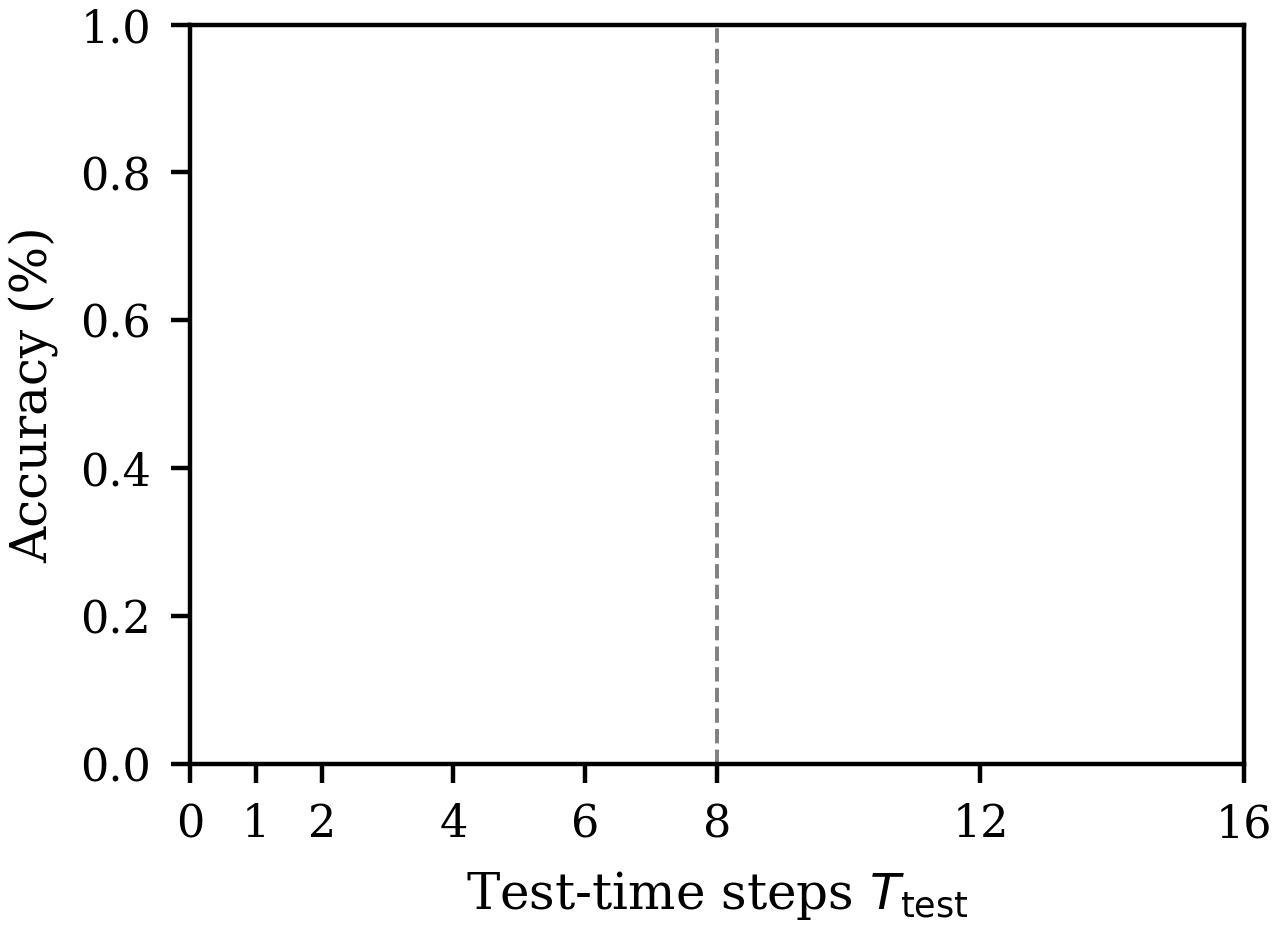

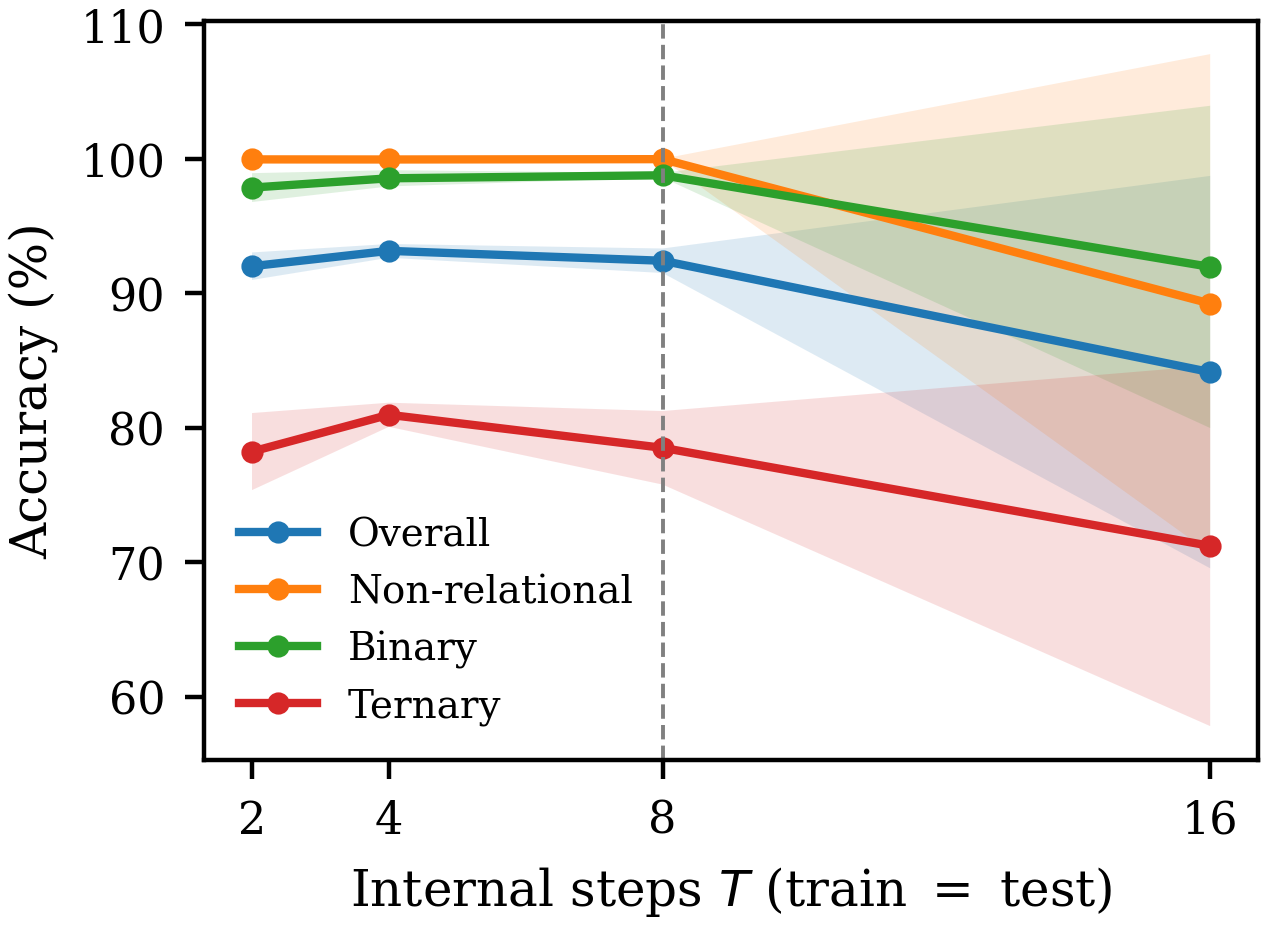

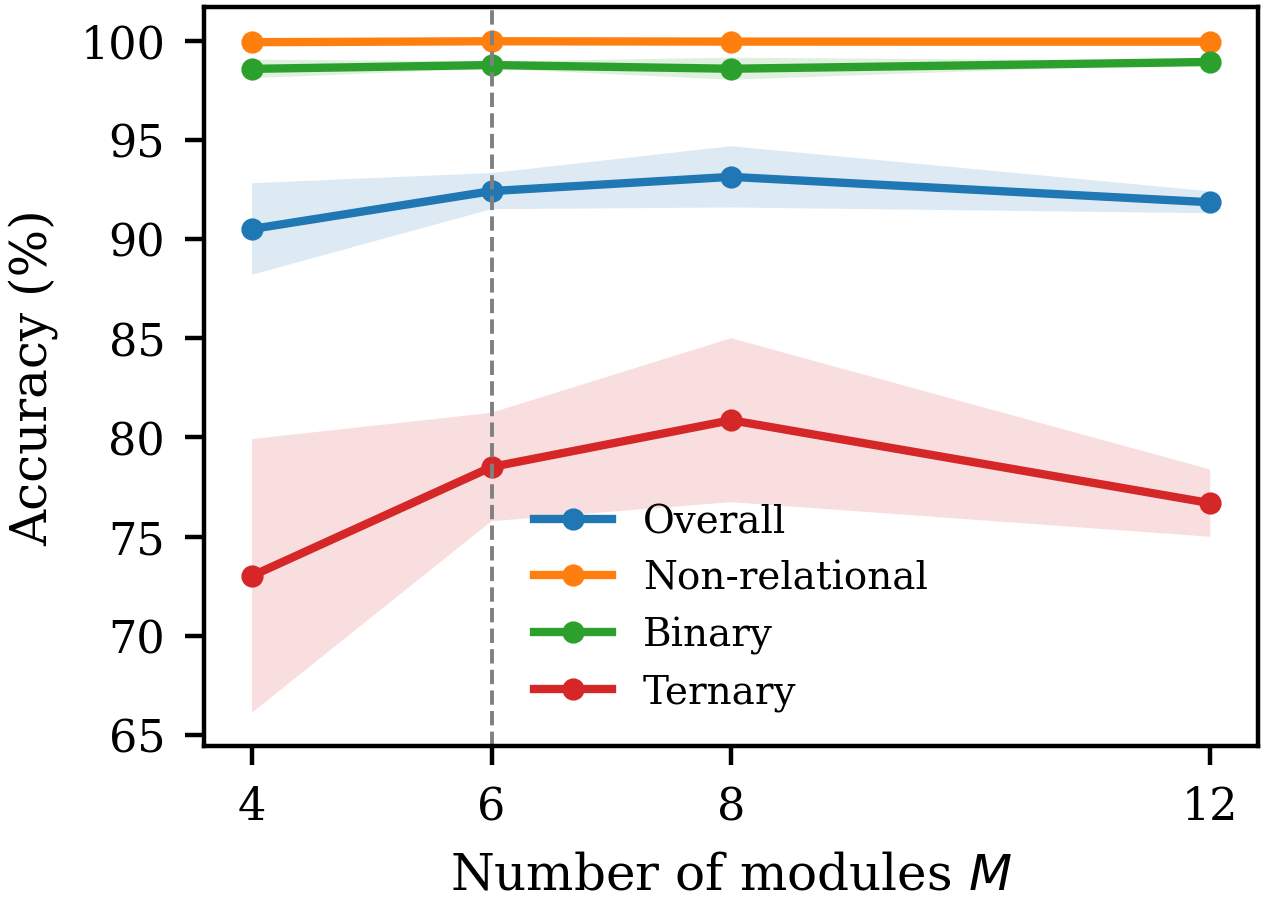

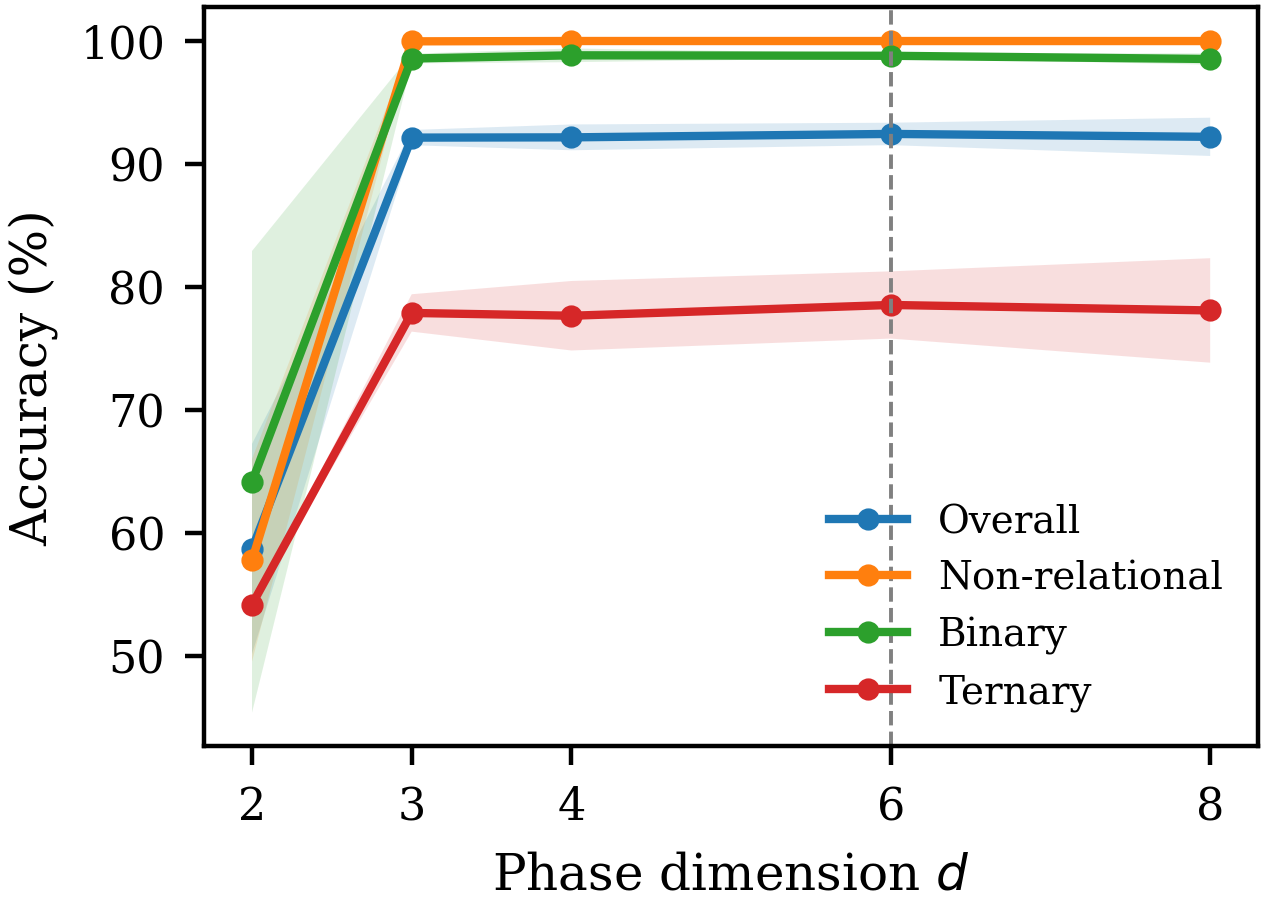

In [10]:
# ======================= FIGURES (unchanged plots; absolute accuracy throughout) =======================

def sweep_plot(cells, xlabel, canon, name, cols=lambda x: METRICS[SOC]):
    """cells: {x: cfg_hash}; cols(x): {family: wandb column}. Empty cells are skipped."""
    fig, ax = plt.subplots(figsize=(3.4, 2.4))
    for fam in FAMILIES:
        pts = [(x, *stat(SOC, h, cols(x).get(fam))[:2]) for x, h in cells.items()]
        pts = [(x, m, s) for x, m, s in pts if not np.isnan(m)]
        if pts:
            x, m, s = map(np.array, zip(*pts))
            ax.plot(x, m, marker='o', markersize=3, label=fam)
            ax.fill_between(x, m - s, m + s, alpha=0.15)
    ax.axvline(canon, color='grey', linestyle='--', linewidth=0.7)
    ax.set_xticks(list(cells)); ax.set_xlabel(xlabel); ax.set_ylabel('Accuracy (%)')
    ax.legend(frameon=False, fontsize=7)
    save_show(fig, name, CHAP_RESULTS)


sweep_plot({T: SWEEPS['t_test'] for T in T_TEST}, r'Test-time steps $T_{\mathrm{test}}$', T_CANON, 'soc_ablation_t_test',
           cols=lambda T: {fam: col.format(T) for fam, col in T_VARIANCE.items()})
sweep_plot(SWEEPS['t_train'], r'Internal steps $T$ (train $=$ test)', T_CANON, 'soc_ablation_t_train')
sweep_plot(SWEEPS['n_modules'], r'Number of modules $M$', M_CANON, 'soc_ablation_n_modules')
sweep_plot(SWEEPS['phase_dim'], r'Phase dimension $d$', D_CANON, 'soc_ablation_phase_dim')


In [11]:
# joint (train T, test T) grid: every t_train run carries its own t_variance sweep
tr = [T for T, h in SWEEPS['t_train'].items() if T > 0 and stat(SOC, h, T_VARIANCE['Overall'].format(T))[2]]
te = [T for T in T_TEST if T > 0]
Z = np.array([[stat(SOC, SWEEPS['t_train'][Ttr], T_VARIANCE['Overall'].format(Tte))[0] for Tte in te] for Ttr in tr])
TR, TE = np.meshgrid(np.log2(tr), np.log2(te), indexing='ij')

if len(tr) < 2:
    print(f'joint T grid needs t_variance summaries on ≥2 t_train runs (have {len(tr)})')
else:
    fig = plt.figure(figsize=(4.5, 3.4))
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(TR, TE, Z, cmap='viridis', edgecolor='white', linewidth=0.3)
    diag = [Z[i, te.index(t)] for i, t in enumerate(tr)]
    ax.plot(np.log2(tr), np.log2(tr), diag, color='C3', marker='o', markersize=3, label=r'$T_{\mathrm{test}}=T_{\mathrm{train}}$')
    ax.set_xticks(np.log2(tr), tr); ax.set_yticks(np.log2(te), te)
    ax.set_xlabel(r'$T_{\mathrm{train}}$'); ax.set_ylabel(r'$T_{\mathrm{test}}$'); ax.set_zlabel('Accuracy (%)')
    ax.view_init(elev=25, azim=-128)
    ax.legend(frameon=False, fontsize=7)
    save_show(fig, 'soc_ablation_t_surface', CHAP_RESULTS)

    fig, ax = plt.subplots(figsize=(3.6, 2.8))
    im = ax.imshow(Z, cmap='viridis', origin='lower')
    ax.set_xticks(range(len(te)), te); ax.set_yticks(range(len(tr)), tr)
    ax.set_xlabel(r'$T_{\mathrm{test}}$'); ax.set_ylabel(r'$T_{\mathrm{train}}$')
    fig.colorbar(im, label='Accuracy (%)')
    save_show(fig, 'soc_ablation_t_heatmap', CHAP_RESULTS)


joint T grid needs t_variance summaries on ≥2 t_train runs (have 0)


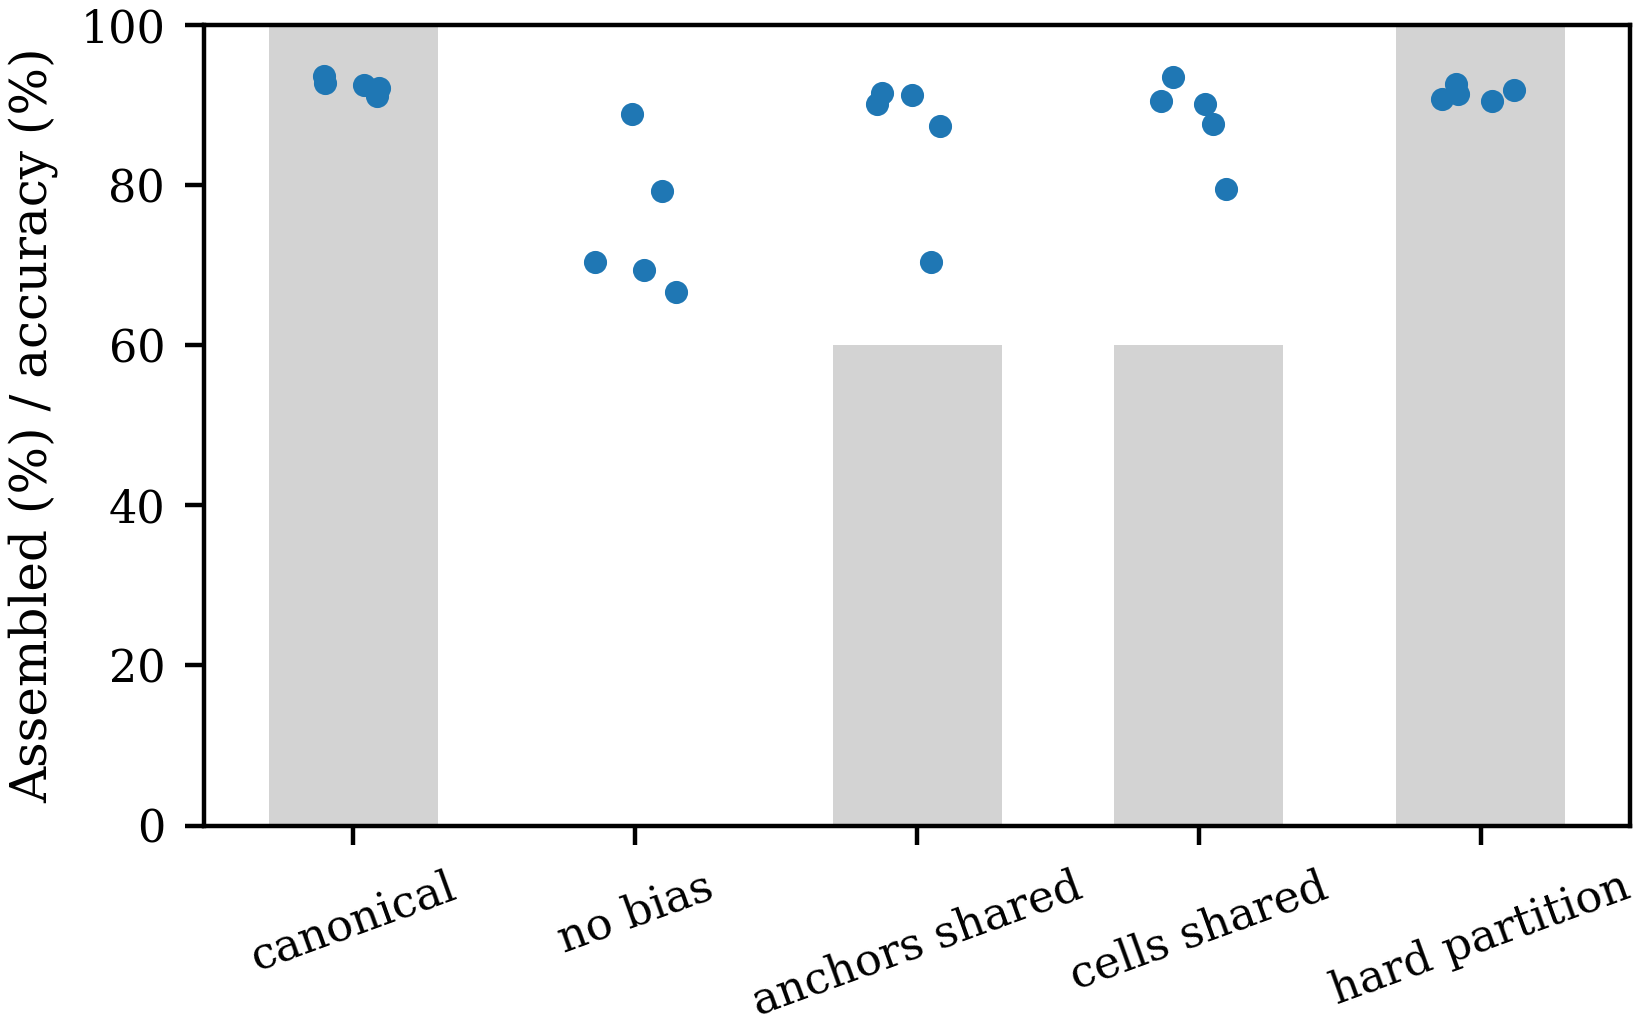

In [12]:
# ---- assembly-rate figure: bars = fraction of runs assembled, points = every run's accuracy ----
variants = {'canonical': ABLATIONS[SOC]['canonical'], 'no bias': ABLATIONS[SOC]['no_bias'],
            'anchors shared': ABLATIONS[SOC]['anchors_off'], 'cells shared': ABLATIONS[SOC]['cells_off'],
            'hard partition': ABLATIONS[SOC]['hard_partition']}
col, thr = ASSEMBLED
fig, ax = plt.subplots(figsize=(4.6, 2.6))
for i, (label, h) in enumerate(variants.items()):
    r = runs(SOC, h)
    if r.empty: continue
    ok = (r[col] > thr).mean()
    ax.bar(i, 100 * ok, color='lightgrey', width=0.6)
    ax2 = ax if i == 0 else ax2
    ax.scatter(np.full(len(r), i) + np.random.uniform(-0.15, 0.15, len(r)), 100 * r[METRICS[SOC]['Overall']],
               s=10, color='C0', zorder=3)
ax.set_xticks(range(len(variants)), list(variants), rotation=20)
ax.set_ylabel('Assembled (%) / accuracy (%)'); ax.set_ylim(0, 100)
save_show(fig, 'soc_assembly_rate', CHAP_RESULTS)


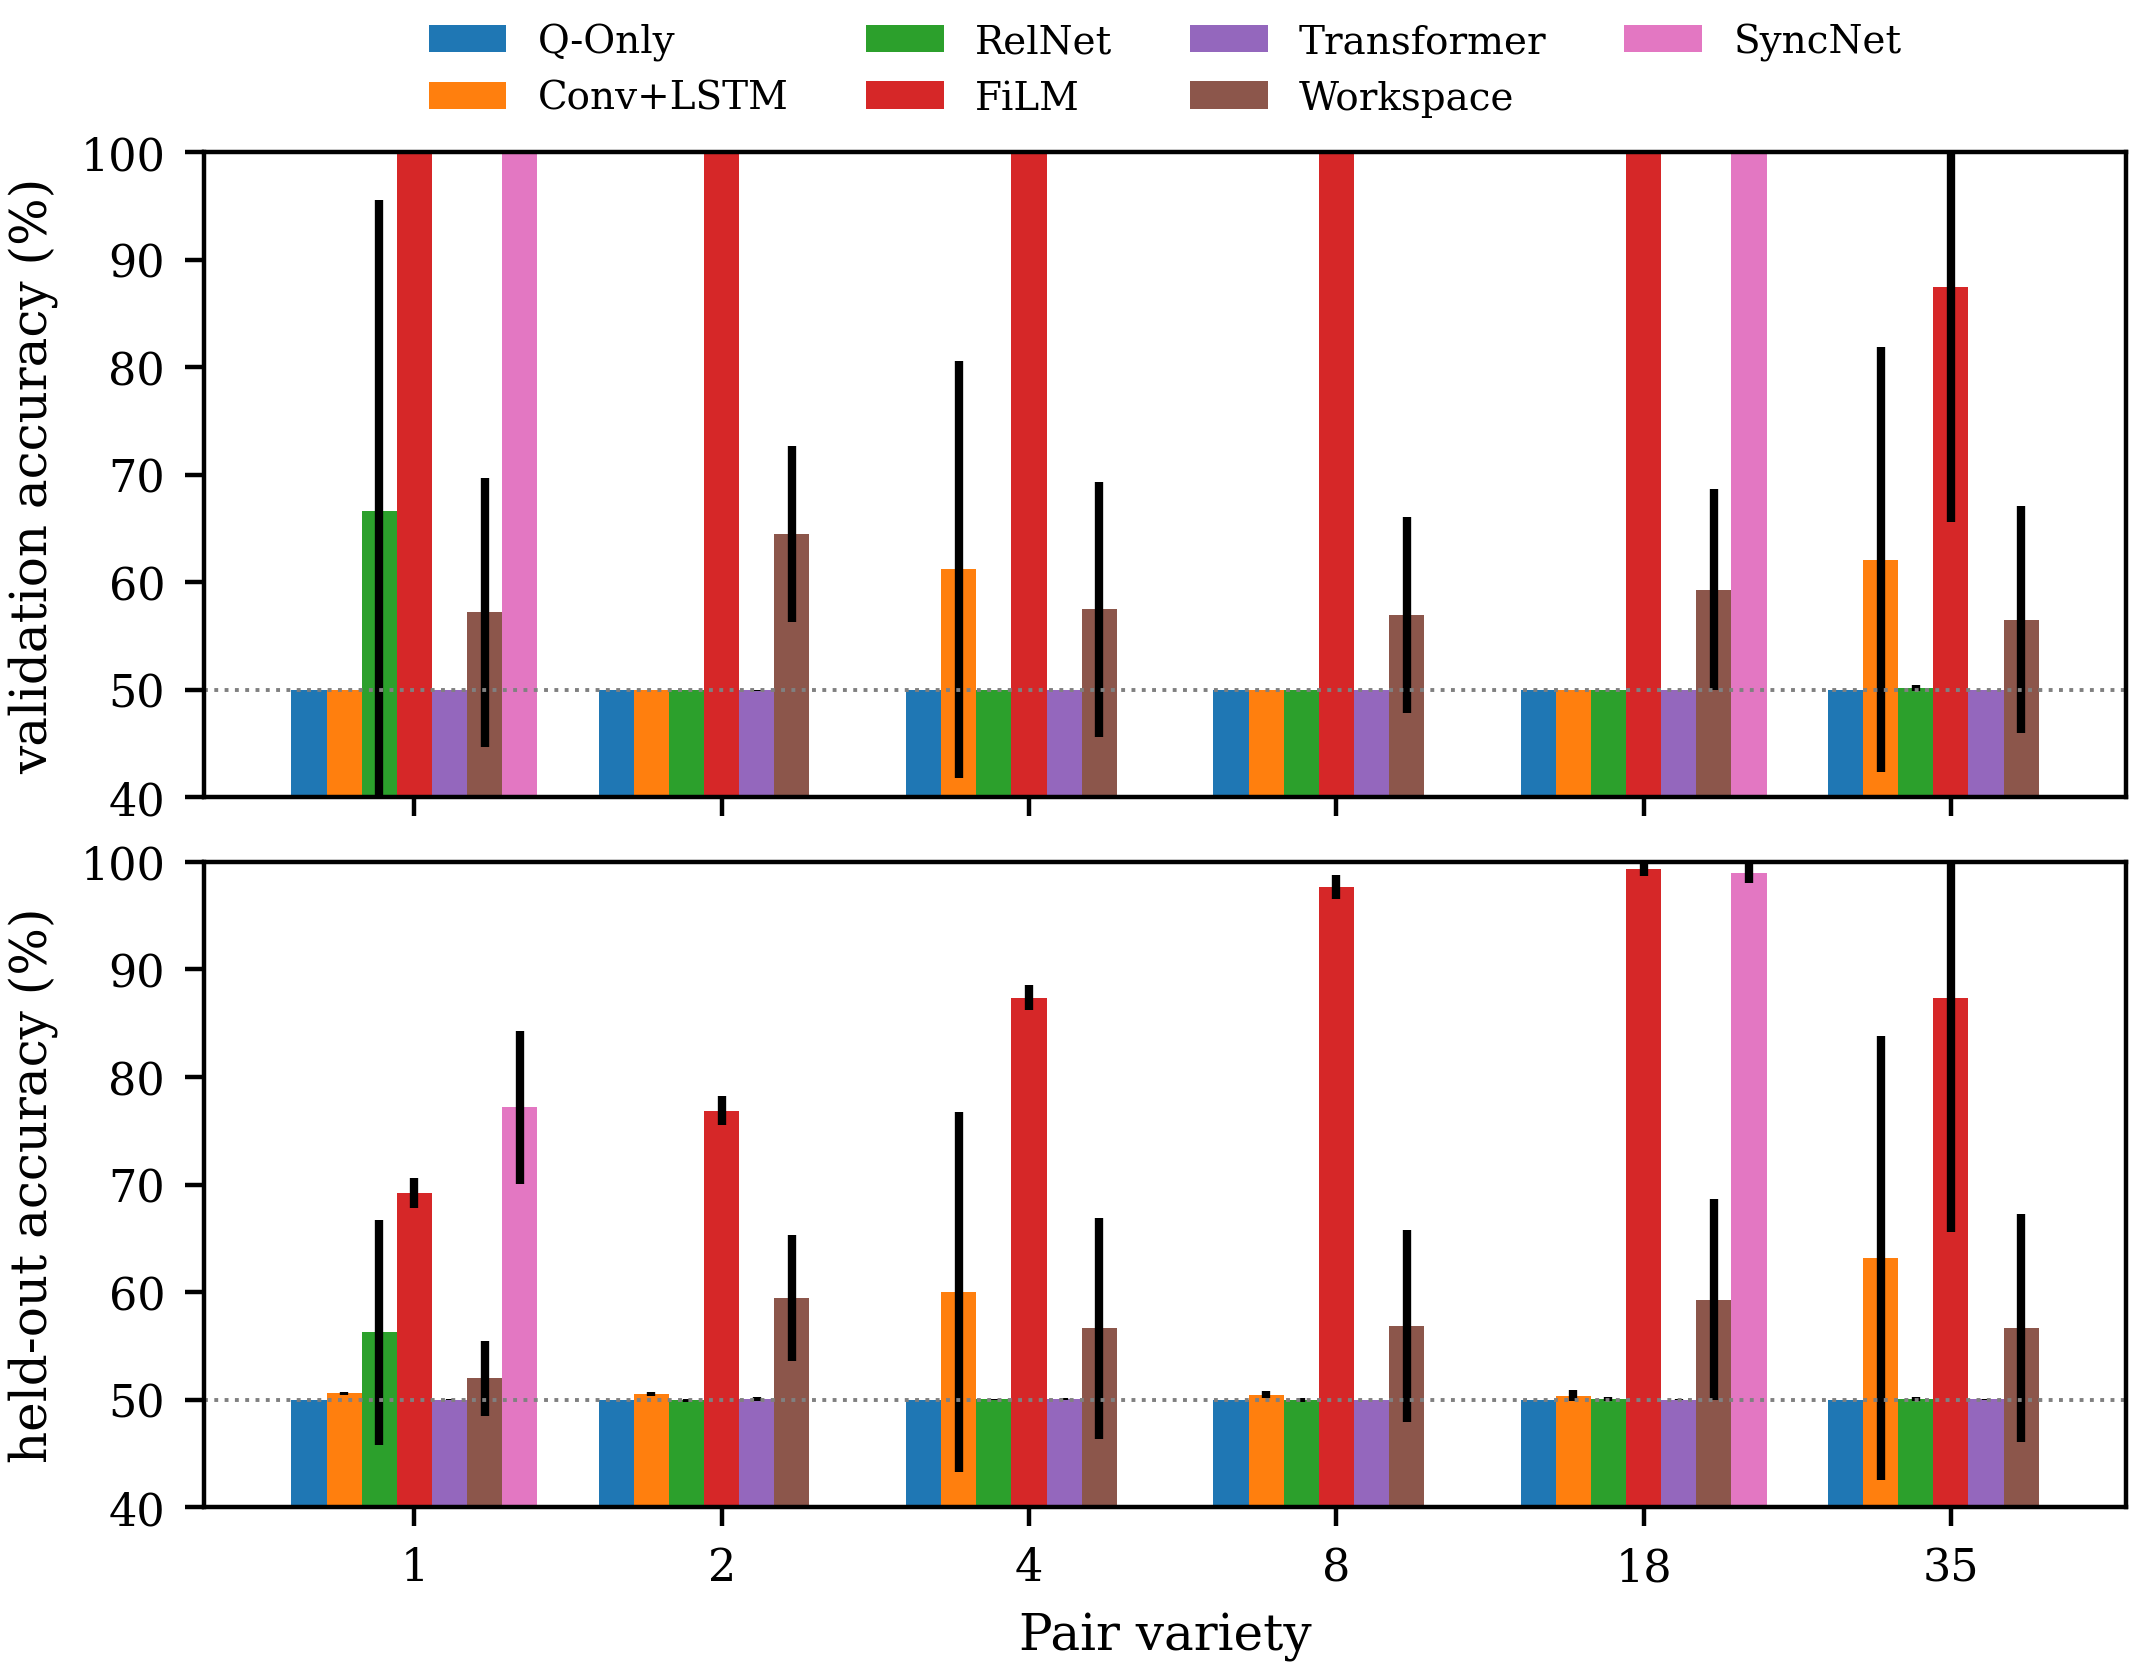

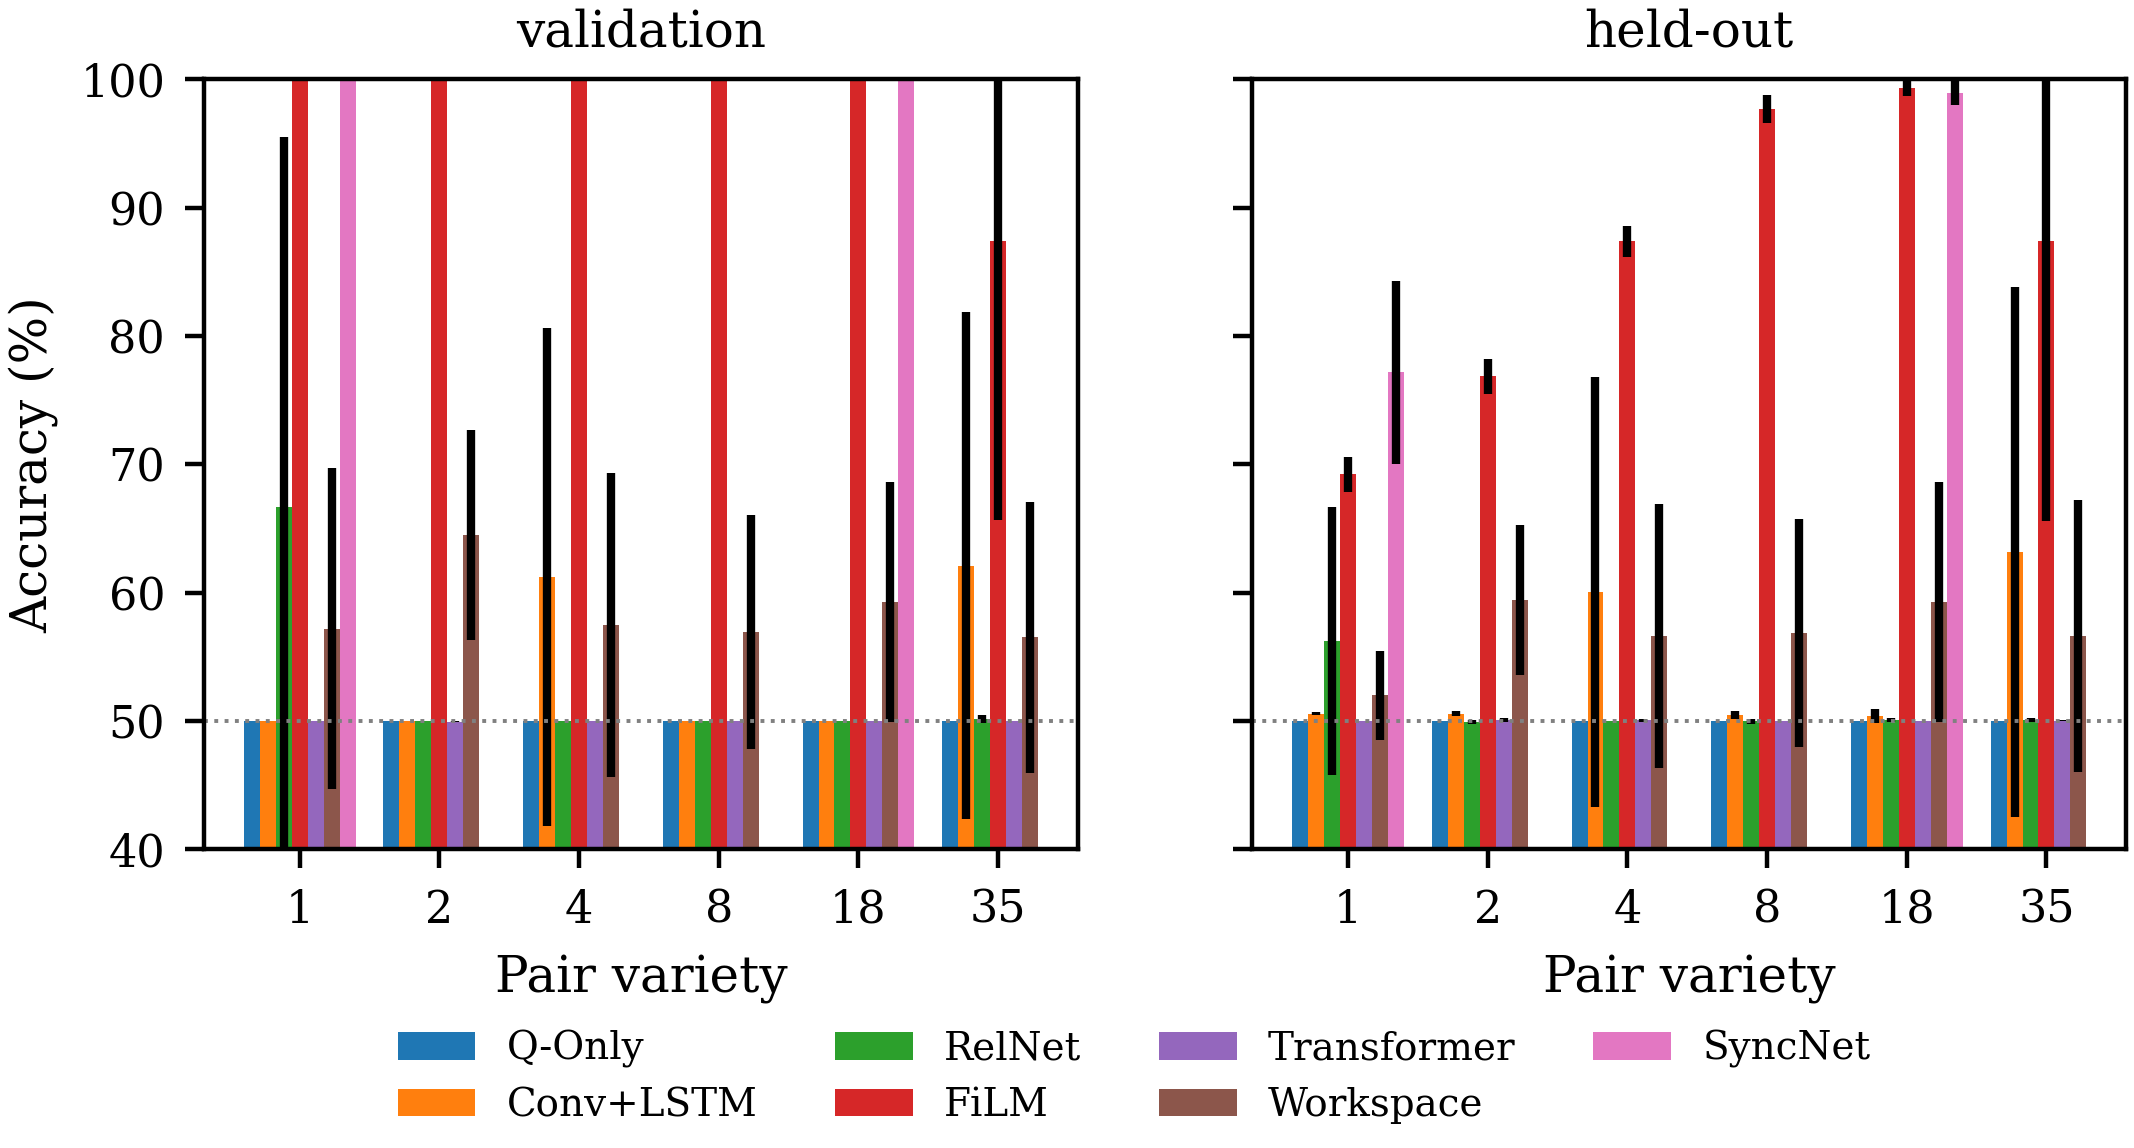

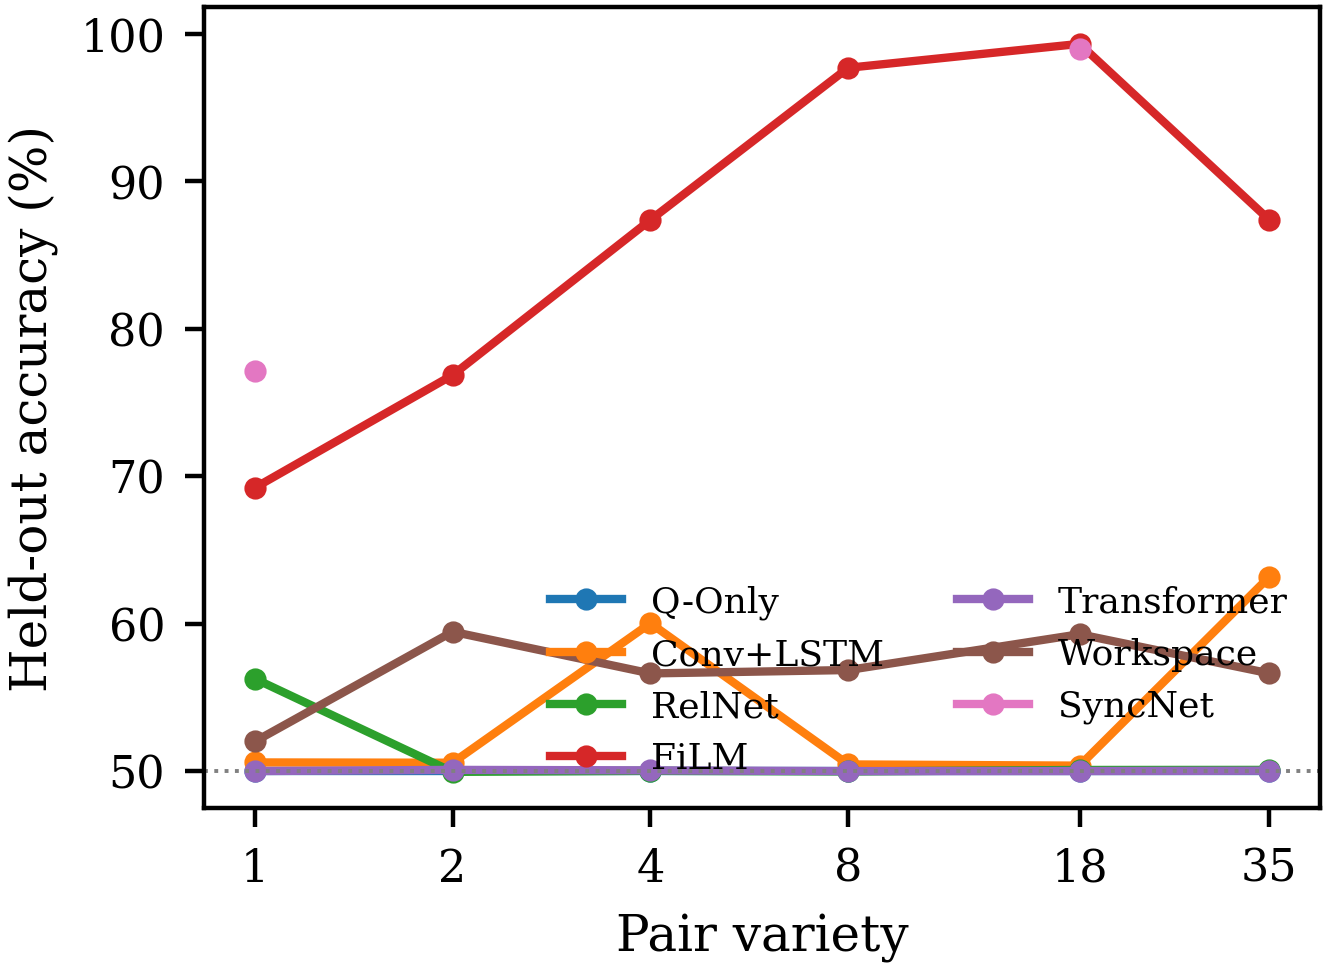

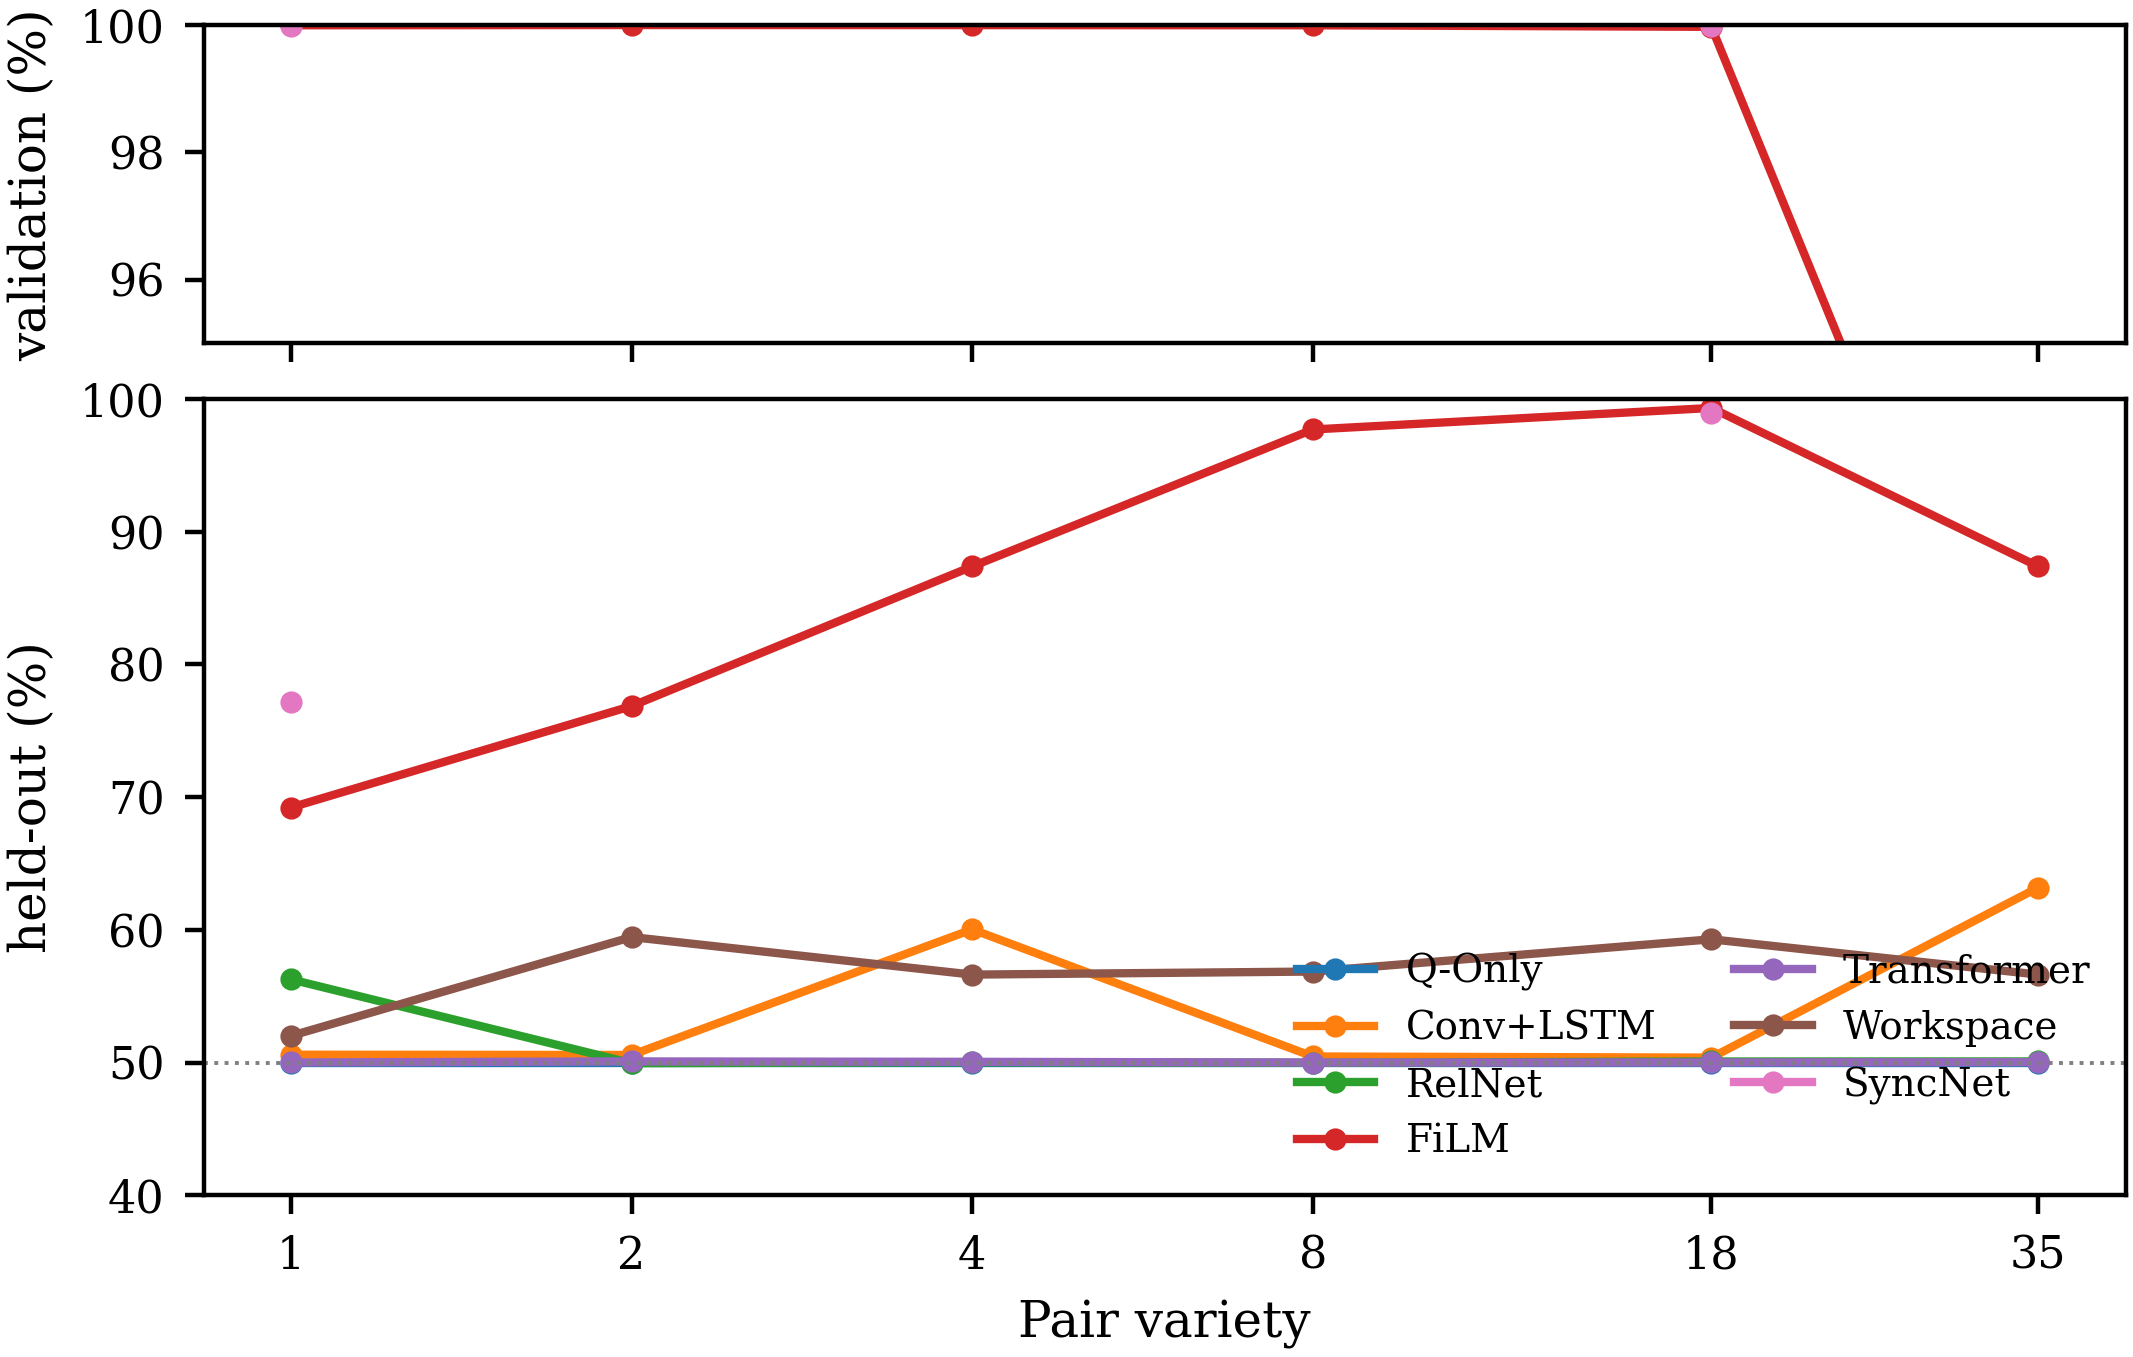

In [13]:
# ---- SQOOP: bars (stacked and side by side) and lines; all absolute accuracy ----
def sq(name, v, split):
    return stat(SQ, MAIN[SQ][name].get(v), METRICS[SQ][split])[:2]


SQOOP_MODELS = [name for name in MAIN[SQ] if any(not np.isnan(sq(name, v, 'held-out')[0]) for v in PAIR_VARIETY)]
x = np.arange(len(PAIR_VARIETY)); w = 0.8 / max(len(SQOOP_MODELS), 1)


def bars(ax, split):
    for k, name in enumerate(SQOOP_MODELS):
        m, s = zip(*[sq(name, v, split) for v in PAIR_VARIETY])
        ax.bar(x + (k - len(SQOOP_MODELS) / 2 + 0.5) * w, m, w, yerr=s, label=name)
    ax.axhline(50, color='grey', linestyle=':', linewidth=0.7); ax.set_ylim(40, 100)


fig, axes = plt.subplots(2, 1, figsize=(6.2, 4.4), sharex=True)
for ax, split in zip(axes, ['validation', 'held-out']):
    bars(ax, split); ax.set_ylabel(f'{split} accuracy (%)')
axes[-1].set_xticks(x, PAIR_VARIETY); axes[-1].set_xlabel('Pair variety')
axes[0].legend(frameon=False, fontsize=7, ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.0))
fig.subplots_adjust(hspace=0.1)
save_show(fig, 'sqoop_results_bars_stacked', CHAP_RESULTS)

fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.5), sharey=True)
for ax, split in zip(axes, ['validation', 'held-out']):
    bars(ax, split); ax.set_xticks(x, PAIR_VARIETY); ax.set_xlabel('Pair variety'); ax.set_title(split)
axes[0].set_ylabel('Accuracy (%)')
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, fontsize=7, ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.2))
save_show(fig, 'sqoop_results_bars', CHAP_RESULTS)

fig, ax = plt.subplots(figsize=(3.6, 2.6))
for name in SQOOP_MODELS:
    ax.plot(PAIR_VARIETY, [sq(name, v, 'held-out')[0] for v in PAIR_VARIETY], marker='o', markersize=3, label=name)
ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
ax.set_xscale('log'); ax.set_xticks(PAIR_VARIETY, PAIR_VARIETY); ax.minorticks_off()
ax.set_xlabel('Pair variety'); ax.set_ylabel('Held-out accuracy (%)')
ax.legend(frameon=False, fontsize=6.5, ncol=2, loc='lower right')
save_show(fig, 'sqoop_results_lines', CHAP_RESULTS)

fig, (ax_val, ax_held) = plt.subplots(2, 1, figsize=(6.2, 3.8), sharex=True, height_ratios=[1, 2.5])
for name in SQOOP_MODELS:
    line, = ax_held.plot(PAIR_VARIETY, [sq(name, v, 'held-out')[0] for v in PAIR_VARIETY], marker='o', markersize=3, label=name)
    ax_val.plot(PAIR_VARIETY, [sq(name, v, 'validation')[0] for v in PAIR_VARIETY], marker='o', markersize=3, color=line.get_color())
ax_val.set_ylim(95, 100); ax_val.set_ylabel('validation (%)')
ax_held.axhline(50, color='grey', linestyle=':', linewidth=0.7); ax_held.set_ylim(40, 100); ax_held.set_ylabel('held-out (%)')
ax_held.set_xscale('log'); ax_held.set_xticks(PAIR_VARIETY, PAIR_VARIETY); ax_held.minorticks_off(); ax_held.set_xlabel('Pair variety')
ax_held.legend(frameon=False, fontsize=7, ncol=2, loc='lower right')
fig.subplots_adjust(hspace=0.1)
save_show(fig, 'sqoop_results_lines_split', CHAP_RESULTS)
